In [1]:
import torch
import matplotlib.pyplot as plt

path = "/Users/debanjan_5402/Desktop/Conditional-GAN-based-Image-Restoration-from-Speckle-Interference-Pattern/_checkpoints/latest_checkpoint_pix2pix.pt"

checkpoint = torch.load(path)
history = checkpoint['history']

In [2]:
train_steps = history['train']['steps']
val_steps = history['val']['steps']

train_g_loss = history['train']['g_loss']
train_g_adv_loss = history['train']['g_adv_loss']
train_g_recon_loss = history['train']['g_recon_loss']

train_d_loss = history['train']['d_loss']
train_d_real_loss = history['train']['d_real_loss']
train_d_fake_loss = history['train']['d_fake_loss']


val_g_loss = history['val']['g_loss']
val_g_adv_loss = history['val']['g_adv_loss']
val_g_recon_loss = history['val']['g_recon_loss']

val_d_loss = history['val']['d_loss']
val_d_real_loss = history['val']['d_real_loss']
val_d_fake_loss = history['val']['d_fake_loss']

val_ssim = history['val']['ssim']
val_psnr = history['val']['psnr']

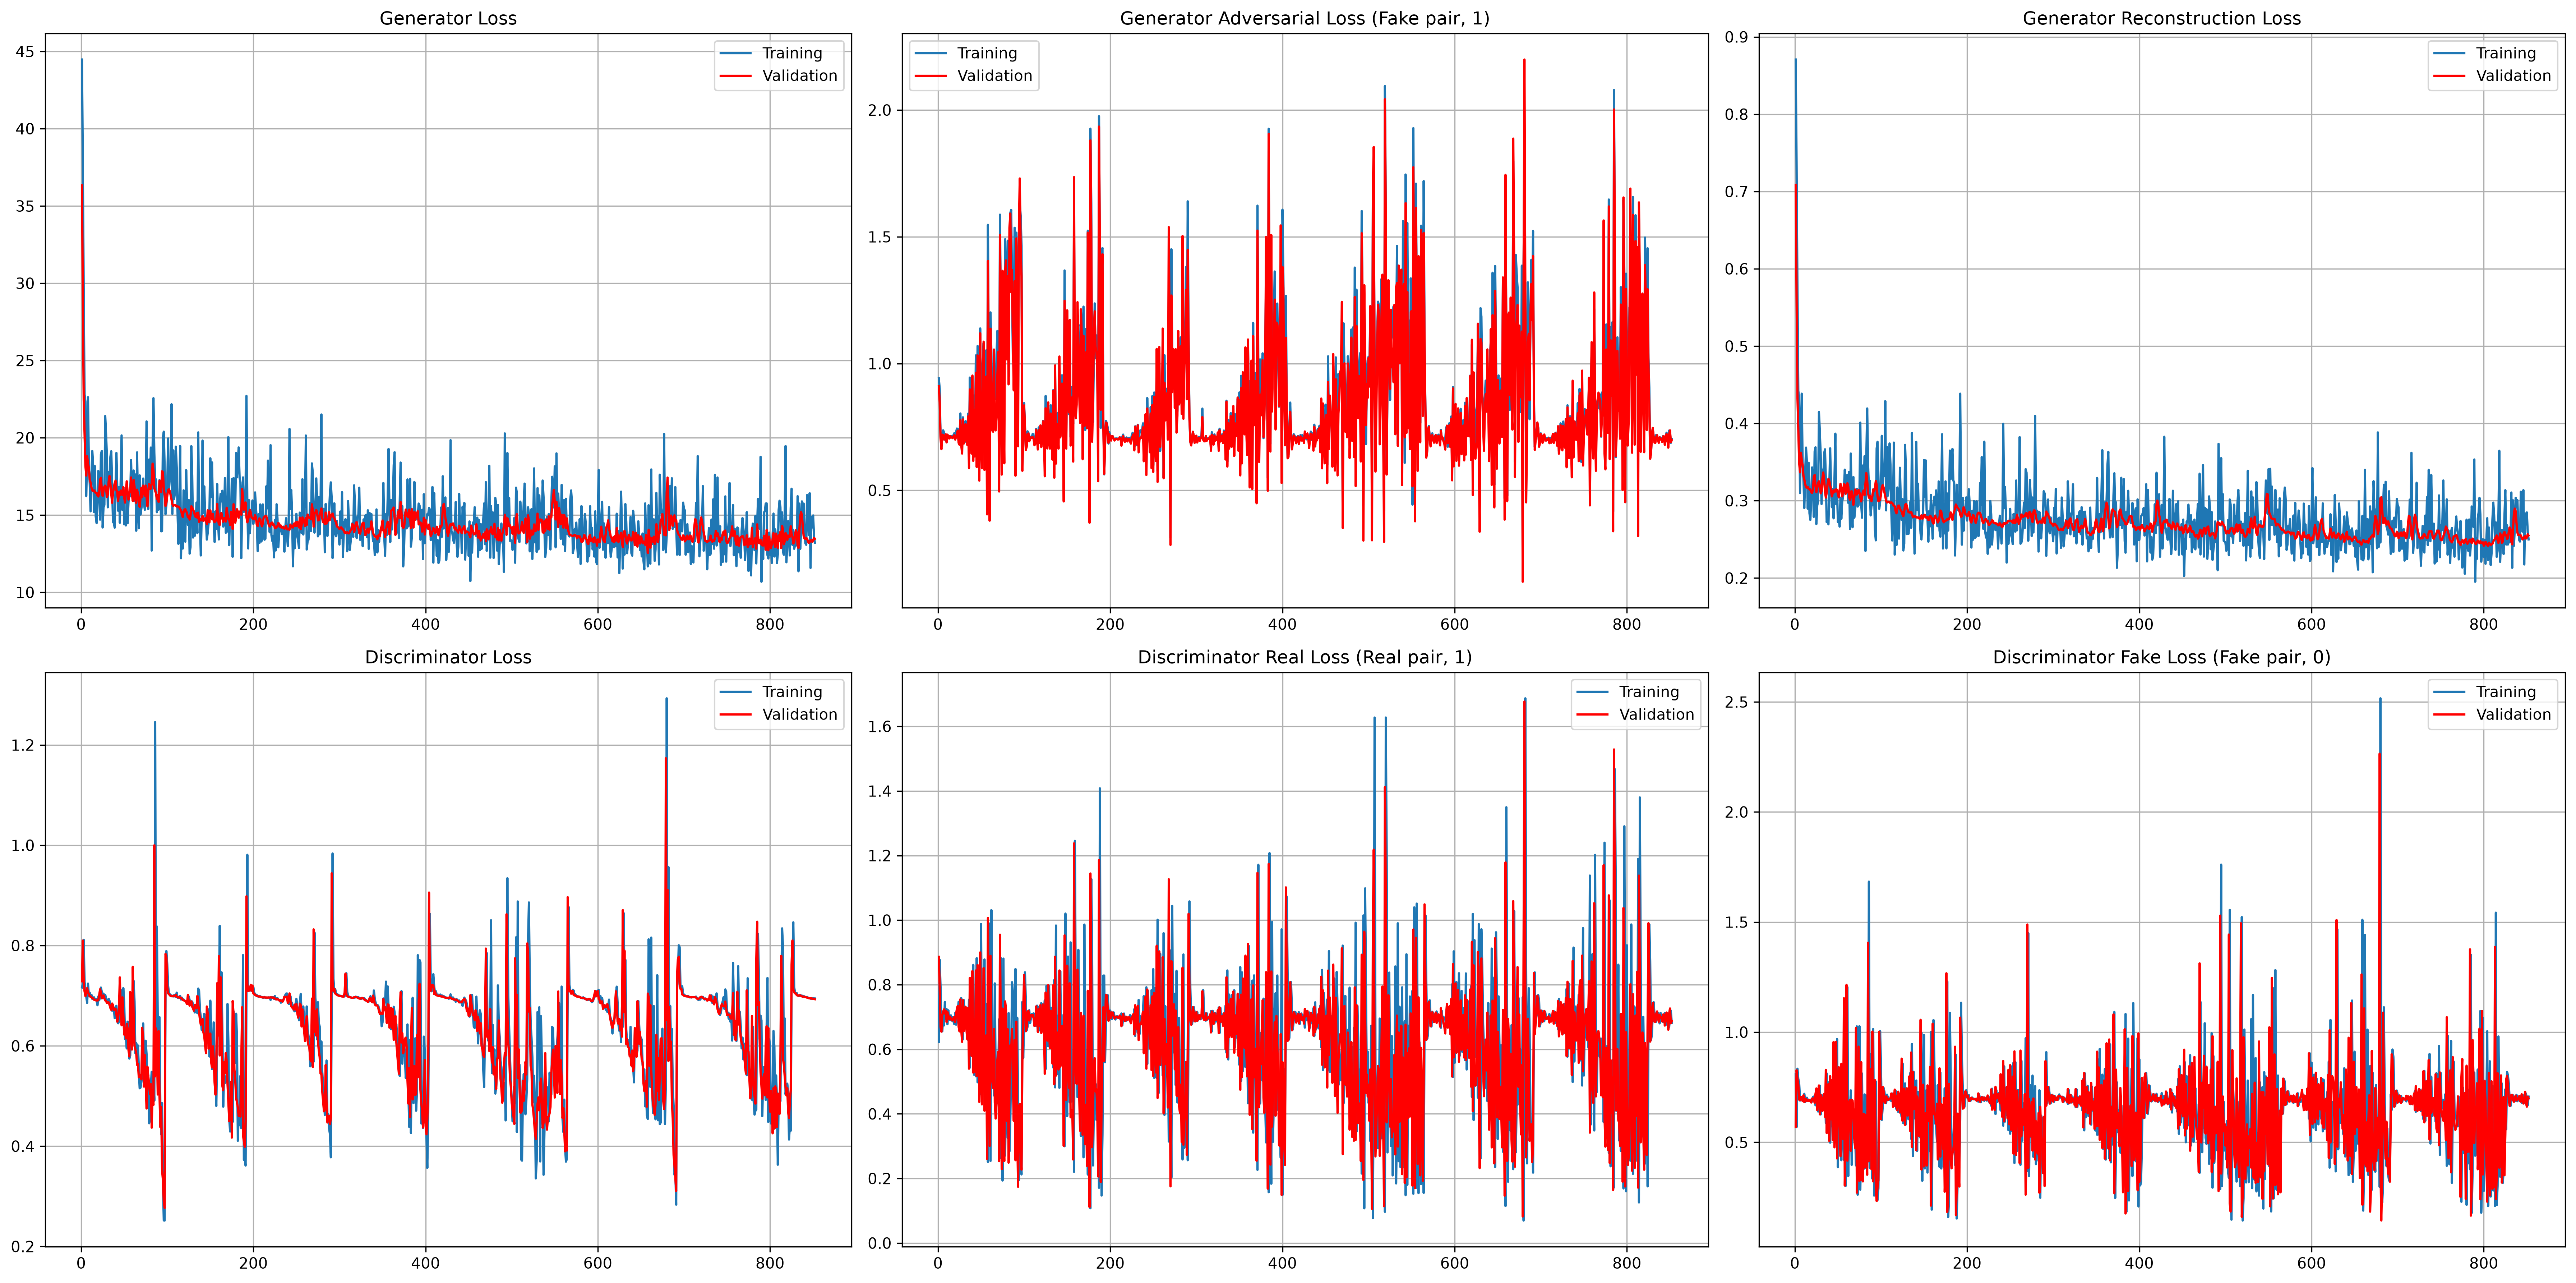

In [3]:
plt.figure(1, figsize=(3*4*2, 2*3*2), dpi=300)

plt.subplot(231)
plt.plot(train_steps, train_g_loss, label="Training")
plt.plot(val_steps, val_g_loss, label="Validation", color='red')
plt.grid()
plt.legend()
plt.title("Generator Loss")

plt.subplot(232)
plt.plot(train_steps, train_g_adv_loss, label="Training")
plt.plot(val_steps, val_g_adv_loss, label="Validation", color='red')
plt.grid()
plt.legend()
plt.title("Generator Adversarial Loss (Fake pair, 1)")

plt.subplot(233)
plt.plot(train_steps, train_g_recon_loss, label="Training")
plt.plot(val_steps, val_g_recon_loss, label="Validation", color='red')
plt.grid()
plt.legend()
plt.title("Generator Reconstruction Loss")

plt.subplot(234)
plt.plot(train_steps, train_d_loss, label="Training")
plt.plot(val_steps, val_d_loss, label="Validation", color='red')
plt.grid()
plt.legend()
plt.title("Discriminator Loss")

plt.subplot(235)
plt.plot(train_steps, train_d_real_loss, label="Training")
plt.plot(val_steps, val_d_real_loss, label="Validation", color='red')
plt.grid()
plt.legend()
plt.title("Discriminator Real Loss (Real pair, 1)")

plt.subplot(236)
plt.plot(train_steps, train_d_fake_loss, label="Training")
plt.plot(val_steps, val_d_fake_loss, label="Validation", color='red')
plt.grid()
plt.legend()
plt.title("Discriminator Fake Loss (Fake pair, 0)")

plt.tight_layout()
plt.show()


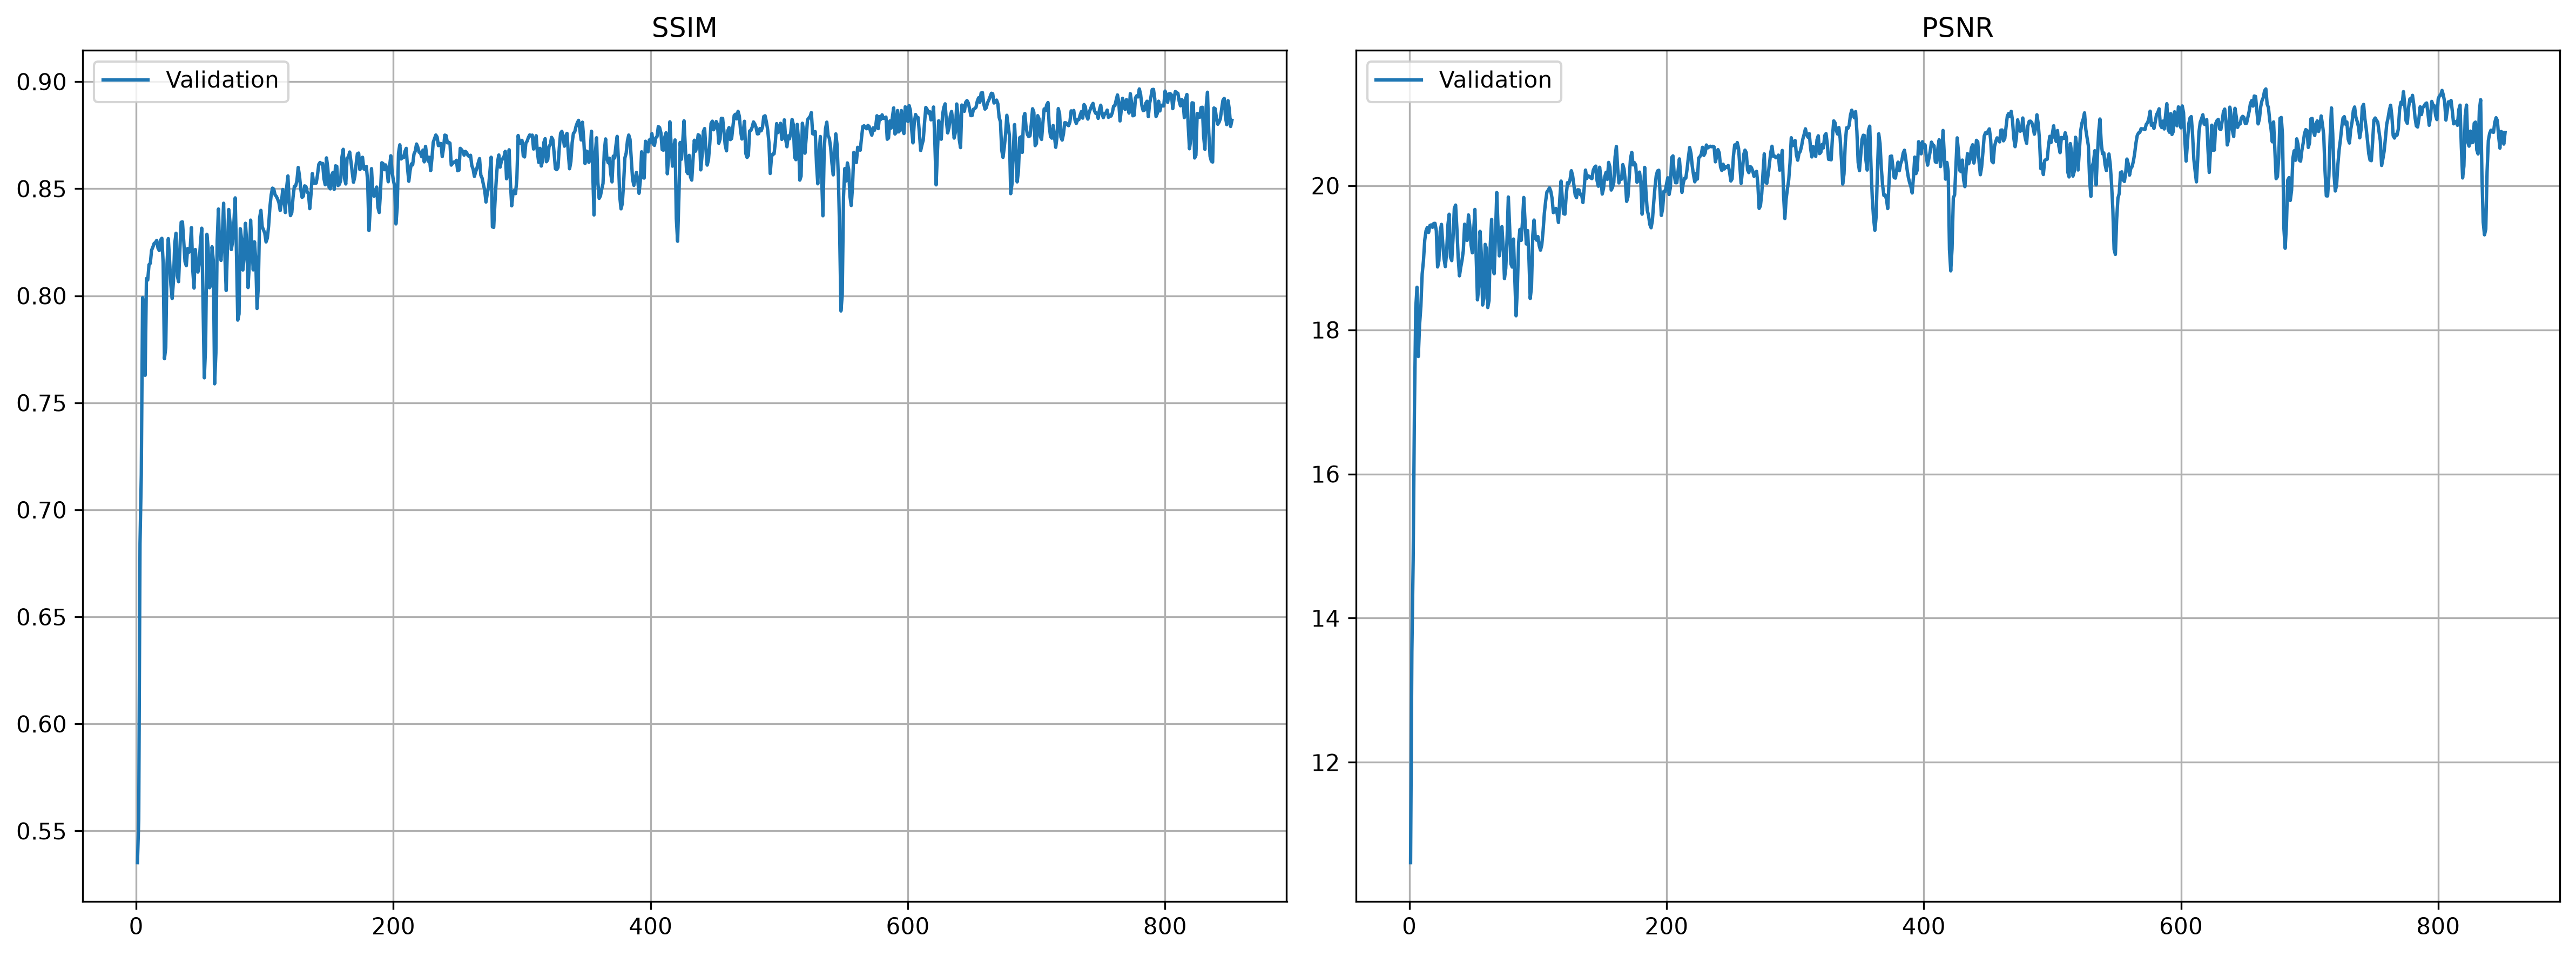

In [4]:
plt.figure(1, figsize=(4*2*2, 3*1*2), dpi=300)

plt.subplot(121)
plt.plot(val_steps, val_ssim, label="Validation")
plt.grid()
plt.legend()
plt.title("SSIM")

plt.subplot(122)
plt.plot(val_steps, val_psnr, label="Validation")
plt.grid()
plt.legend()
plt.title("PSNR")

plt.tight_layout()
plt.show()

In [5]:
print(history['best'])

{'step': 780, 'train_g_loss': 14.444988250732422, 'train_g_adv_loss': 0.6685879230499268, 'train_g_recon_loss': 0.2755280137062073, 'train_d_loss': 0.6382471919059753, 'train_d_real_loss': 1.0608172416687012, 'train_d_fake_loss': 0.21567709743976593, 'val_g_loss': 12.922130036861338, 'val_g_adv_loss': 0.6231962214124963, 'val_g_recon_loss': 0.2459786724536977, 'val_d_loss': 0.5478539010311695, 'val_d_real_loss': 0.24798256412465522, 'val_d_fake_loss': 0.8477252442786034, 'val_ssim': 0.8966114521026611, 'val_psnr': 21.25281524658203}


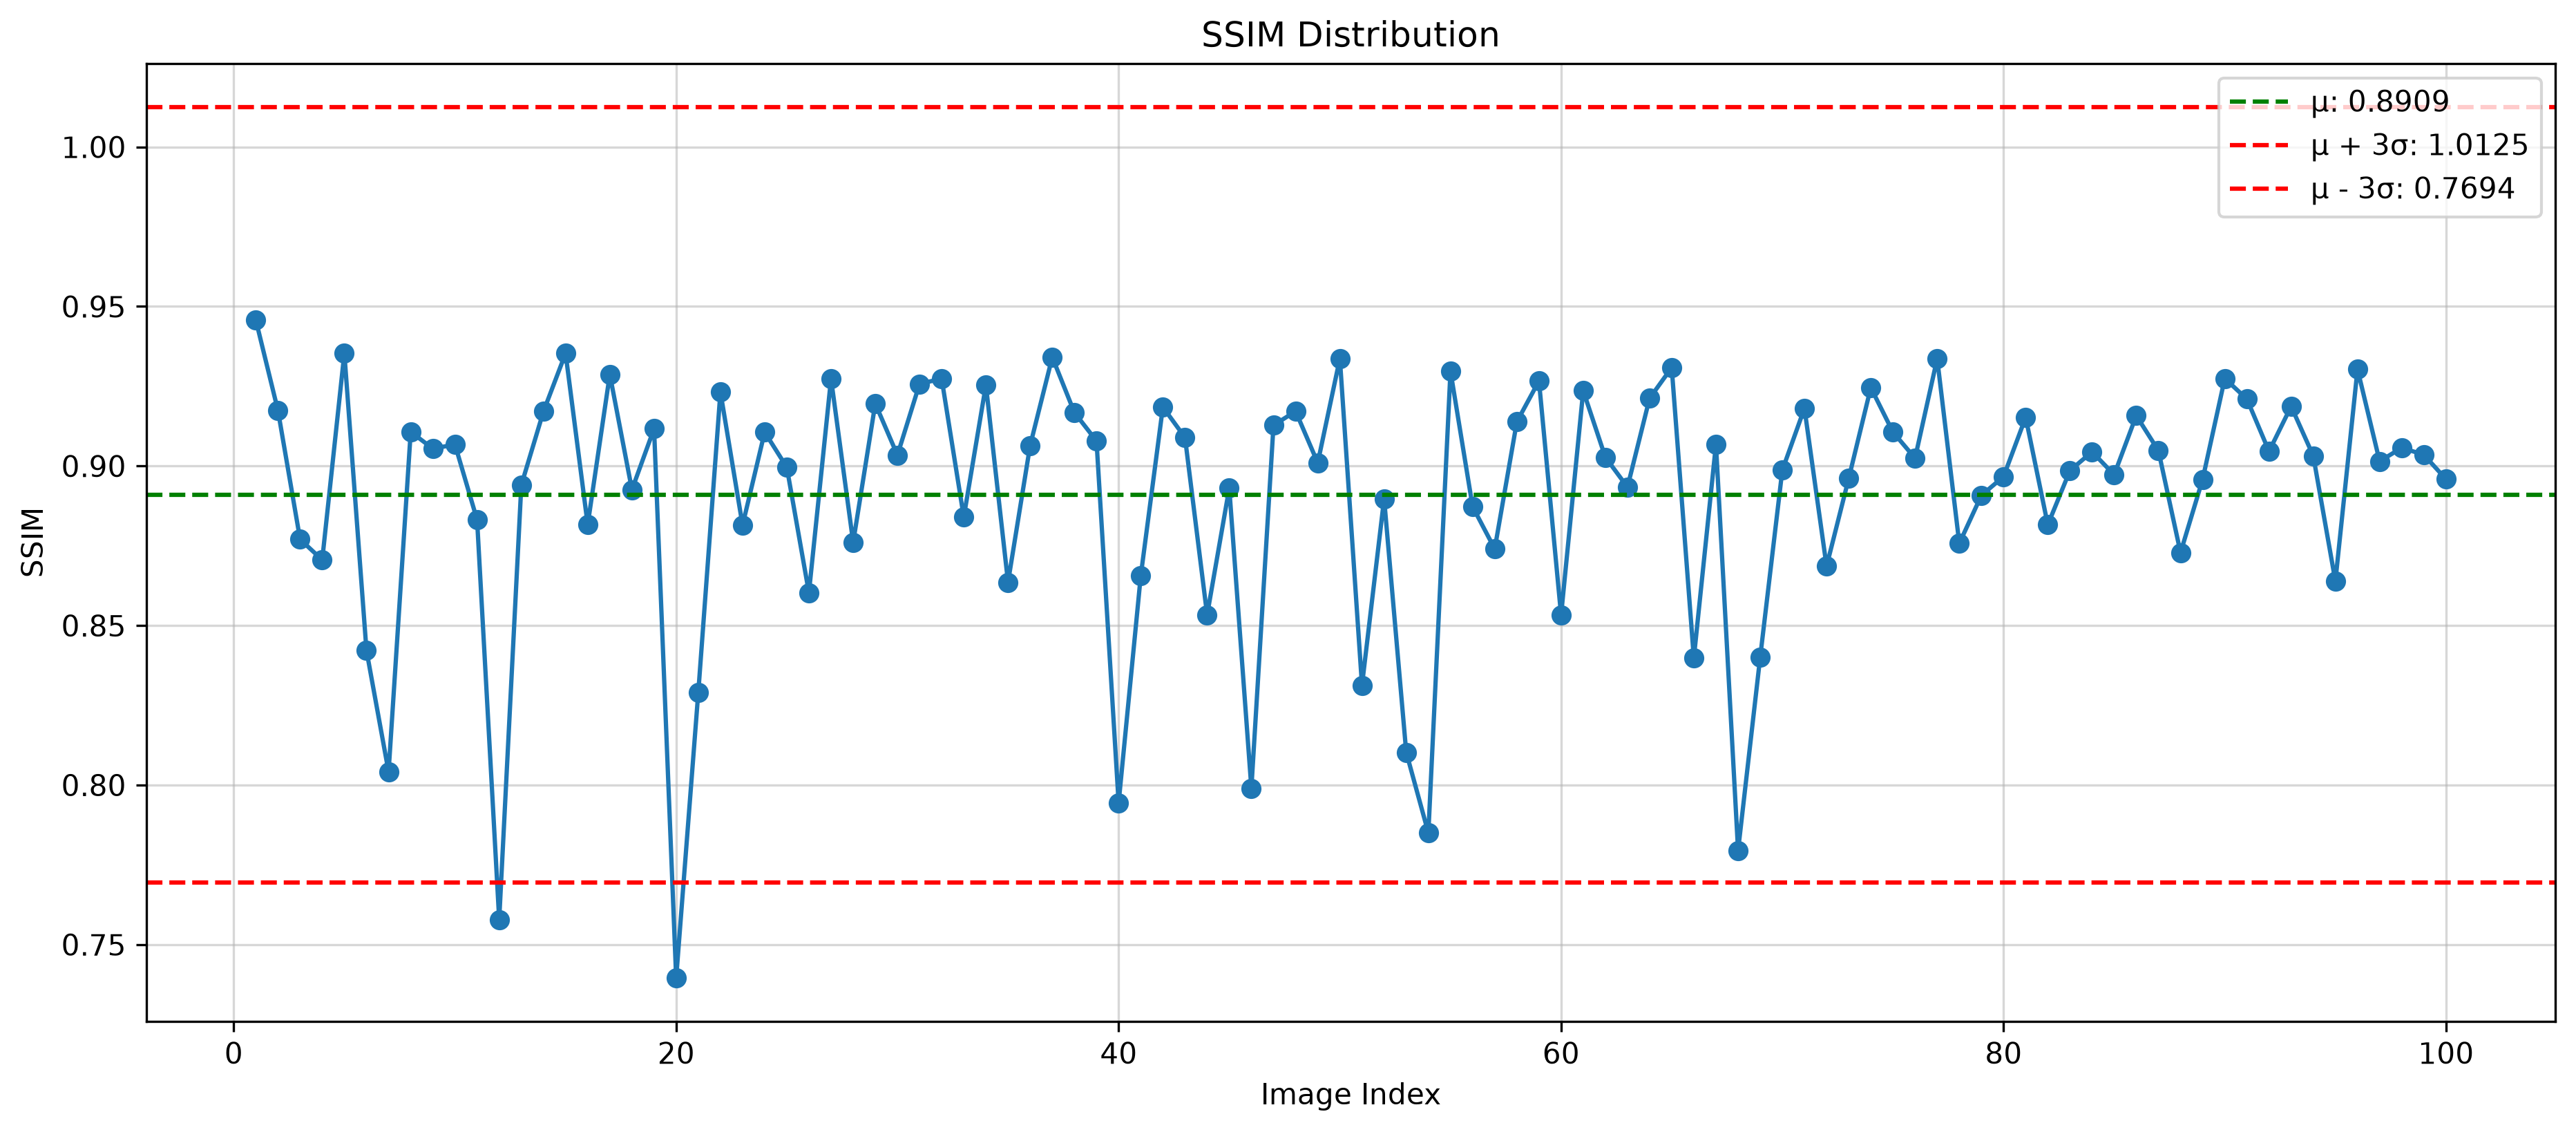

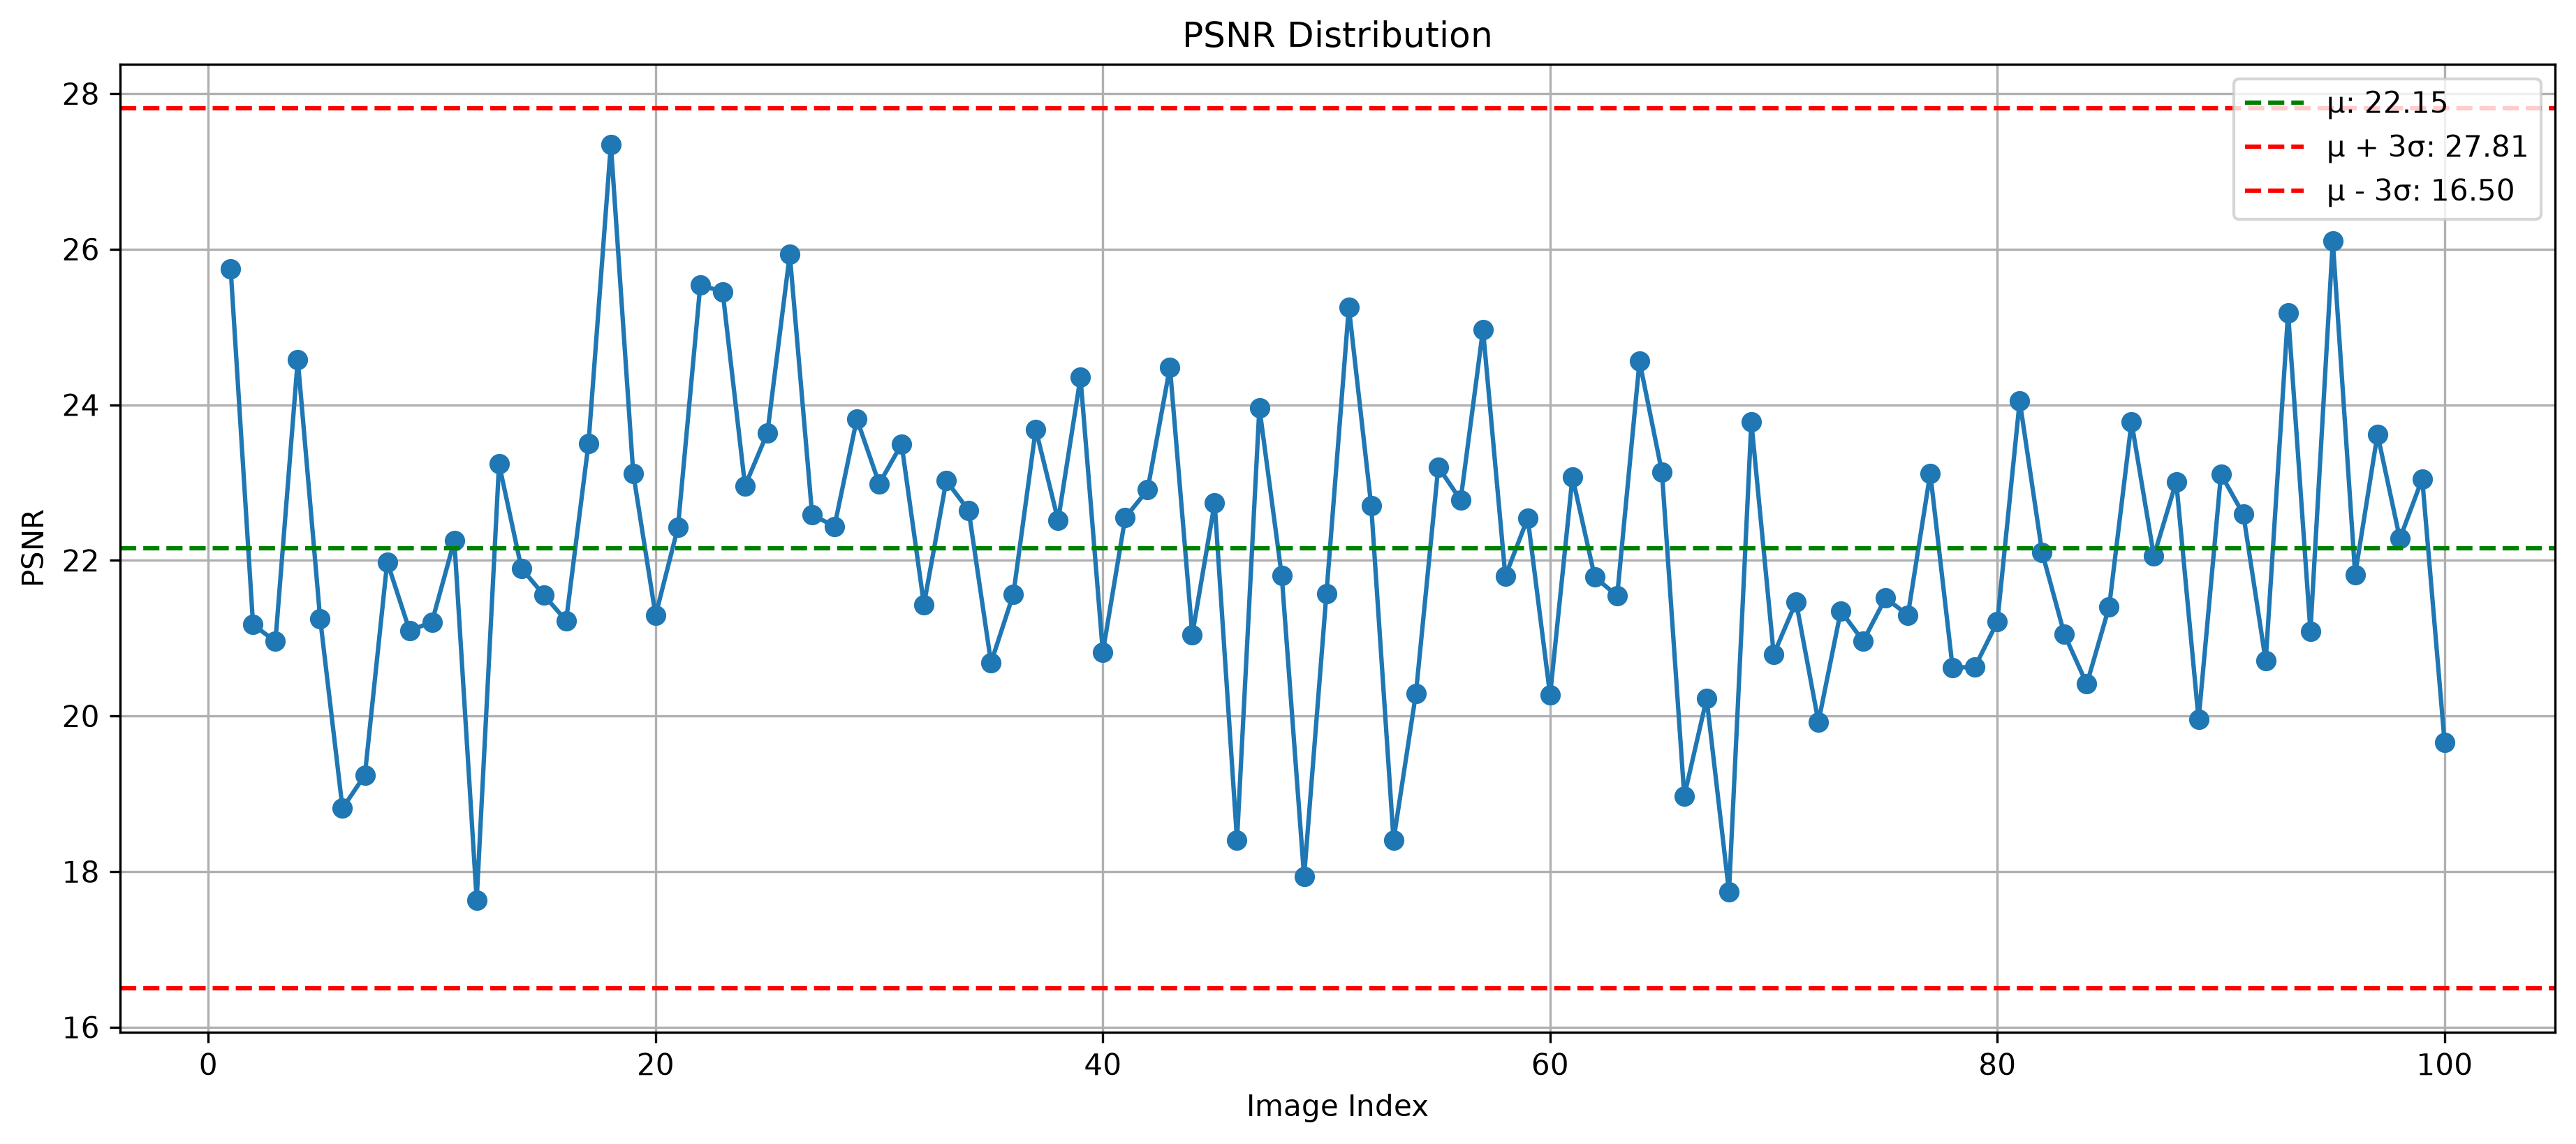

In [6]:
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import math

files = sorted(Path("../dataset/test").glob("img*/img*_pix2pix_data.pt"))

ssim = []
psnr = []

for f in files:
    data = torch.load(f, map_location="cpu", weights_only=False)
    ssim.append(float(data["ssim"]))
    psnr.append(float(data["psnr"]))

μ_ssim = sum(ssim)/len(ssim)
σ_ssim = math.sqrt(sum([(x-μ_ssim)**2 for x in ssim])/len(ssim))
UL_ssim = μ_ssim + 3 * σ_ssim
LL_ssim = μ_ssim - 3 * σ_ssim

μ_psnr = sum(psnr)/len(psnr)
σ_psnr = math.sqrt(sum([(x-μ_psnr)**2 for x in psnr])/len(psnr))
UL_psnr = μ_psnr + 3 * σ_psnr
LL_psnr = μ_psnr - 3 * σ_psnr

plt.figure(figsize=(15, 6), dpi=300)
plt.plot(range(1, len(ssim)+1), ssim, "o-")
plt.axhline(μ_ssim, linestyle="--", color='green', label=f"μ: {μ_ssim:0.4f}")
plt.axhline(UL_ssim, linestyle="--", color='red', label=f"μ + 3σ: {UL_ssim:0.4f}")
plt.axhline(LL_ssim, linestyle="--", color='red', label=f"μ - 3σ: {LL_ssim:0.4f}")
plt.xlabel("Image Index")
plt.ylabel("SSIM")
plt.title("SSIM Distribution")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(15, 6), dpi=300)
plt.plot(range(1, len(psnr)+1), psnr, "o-")
plt.axhline(μ_psnr, linestyle="--", color='green', label=f"μ: {μ_psnr:0.2f}")
plt.axhline(UL_psnr, linestyle="--", color='red', label=f"μ + 3σ: {UL_psnr:0.2f}")
plt.axhline(LL_psnr, linestyle="--", color='red', label=f"μ - 3σ: {LL_psnr:0.2f}")
plt.xlabel("Image Index")
plt.ylabel("PSNR")
plt.title("PSNR Distribution")
plt.grid(alpha=1.0)
plt.legend()
plt.show()

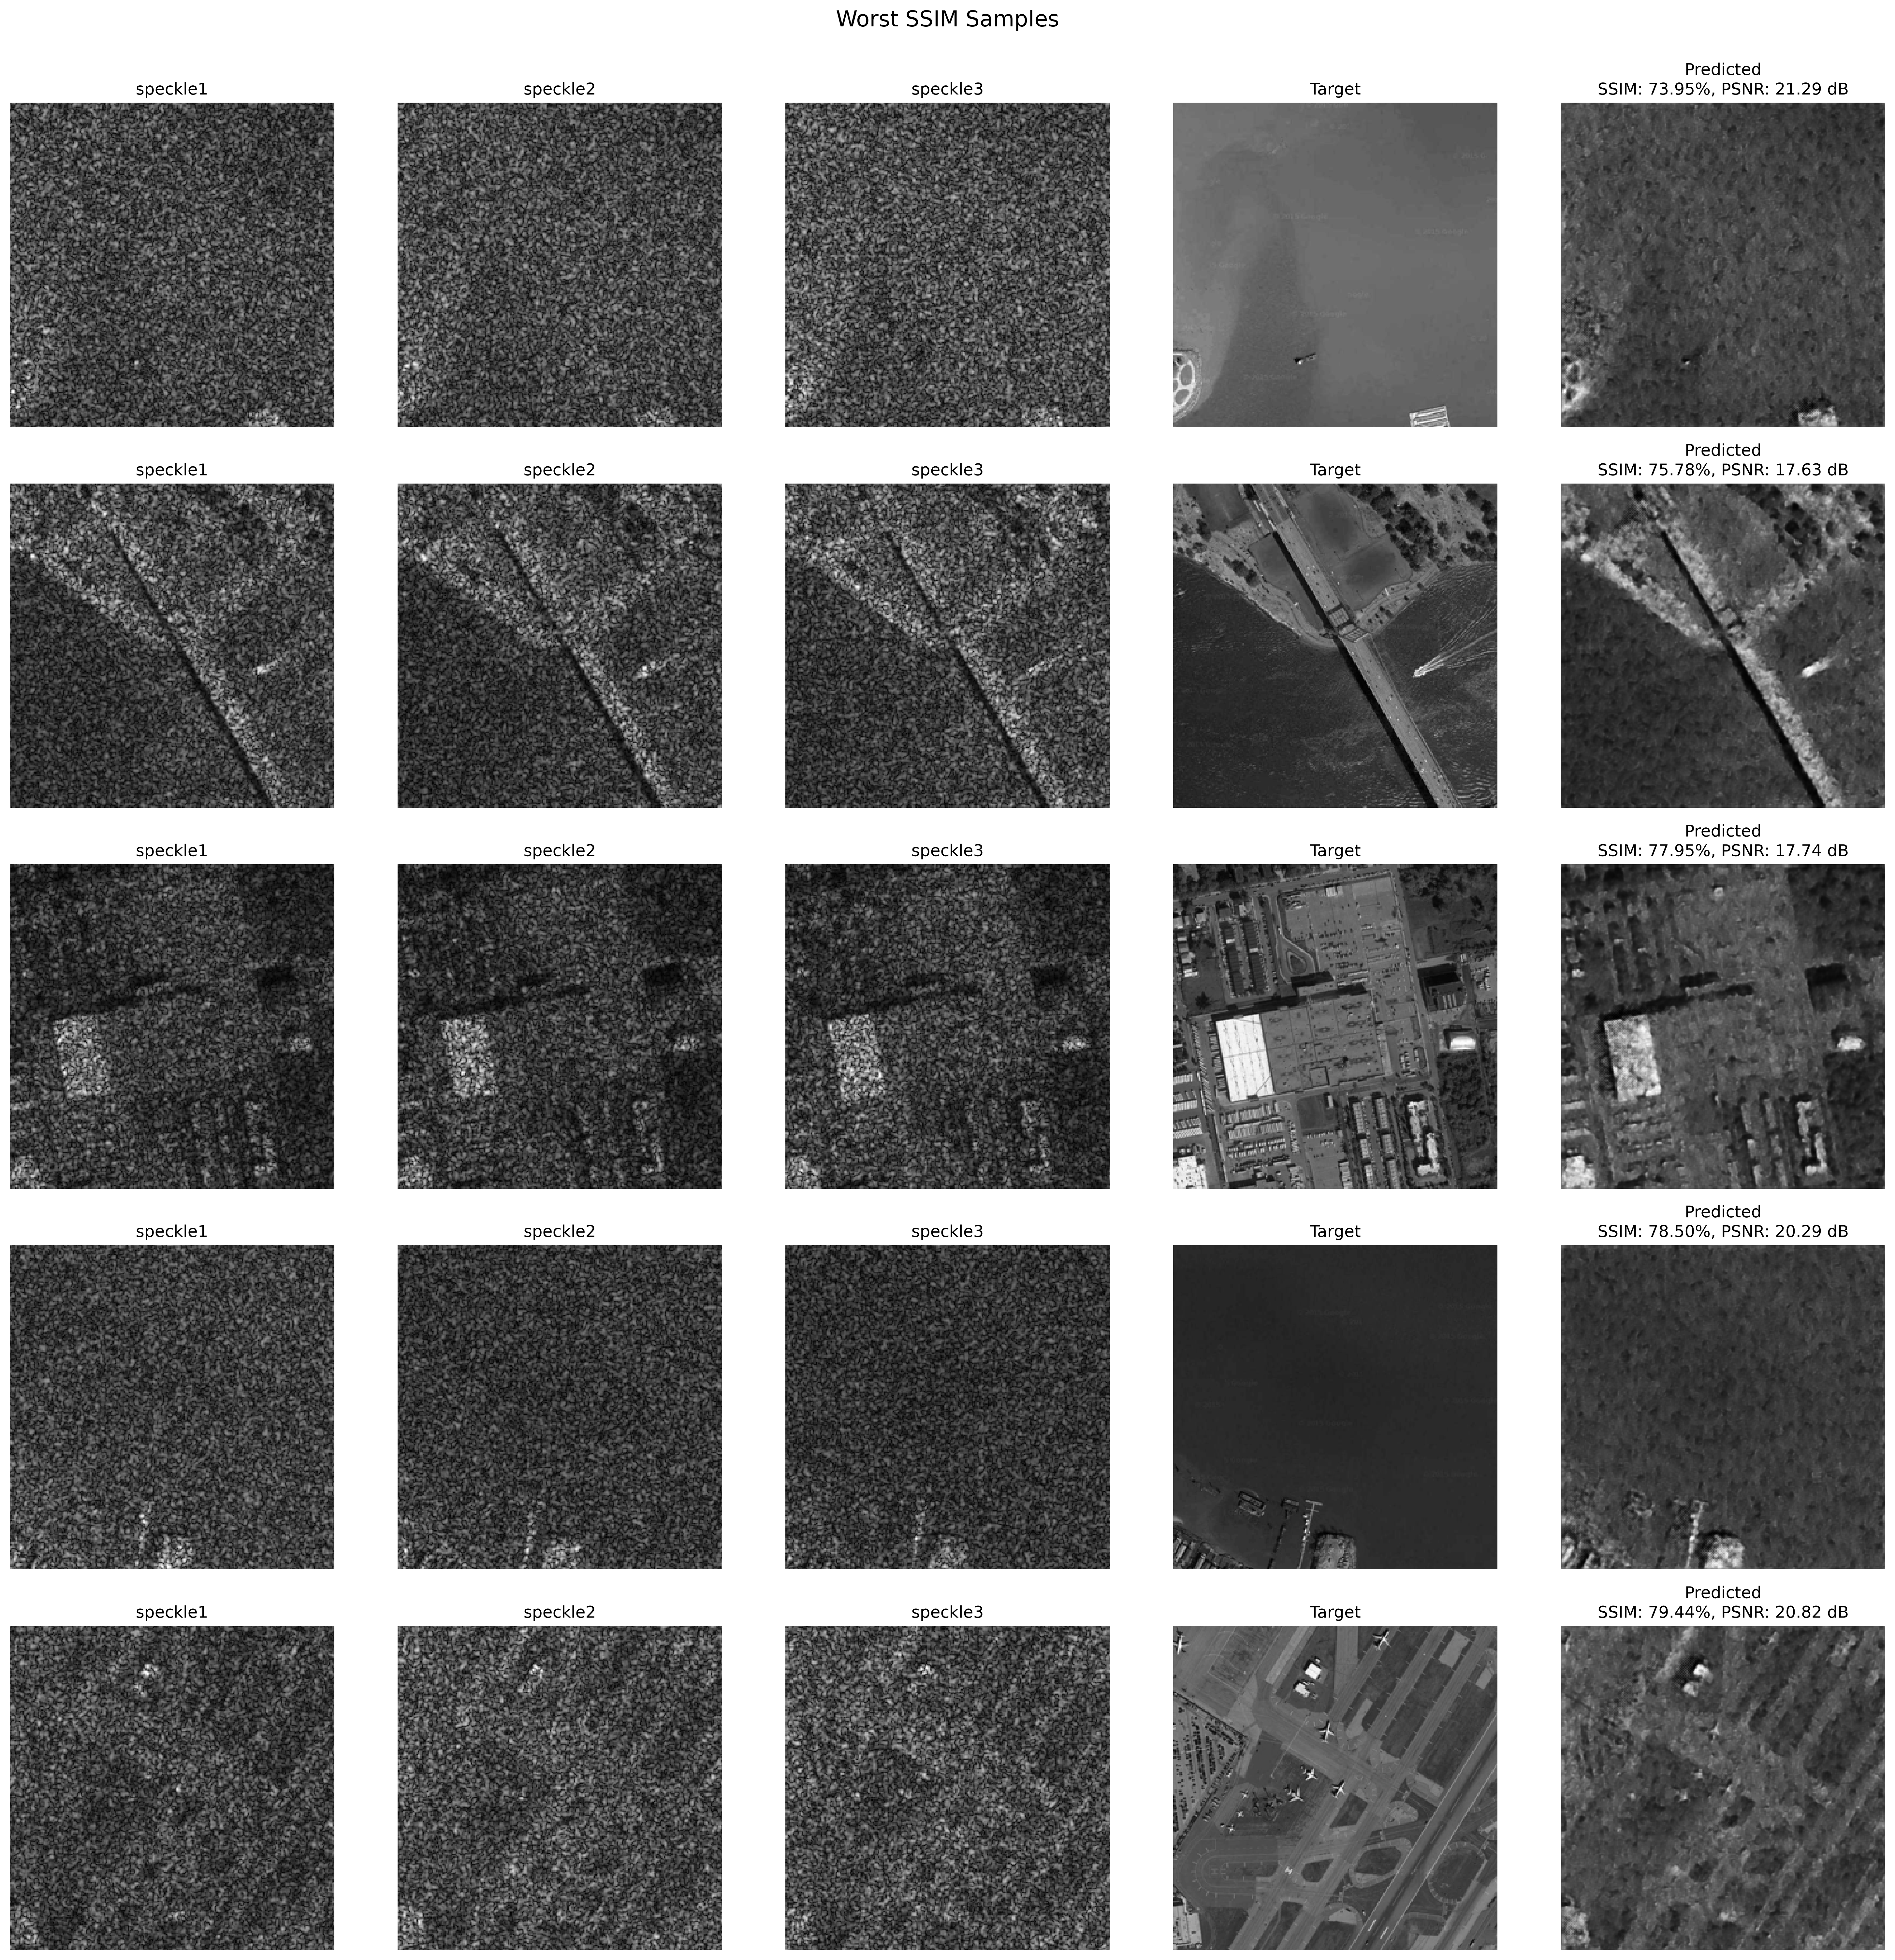

In [7]:
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import random

num_samples = 5
mode = "worst"   # "best", "worst", or "random"
mode = mode.lower()

test_dir = Path("../dataset/test")

# Load all results
results = []

for path in test_dir.glob("img*/img*_pix2pix_data.pt"):
    data = torch.load(path, map_location="cpu", weights_only=False)
    results.append((float(data["ssim"]), path, data))

# Select samples
if mode == "best":
    results.sort(key=lambda x: x[0], reverse=True)
    selected = results[:num_samples]

elif mode == "worst":
    results.sort(key=lambda x: x[0])
    selected = results[:num_samples]

elif mode == "random":
    selected = random.sample(results, min(num_samples, len(results)))

else:
    raise ValueError("mode must be 'best', 'worst', or 'random'")


# Plot
fig, axes = plt.subplots(len(selected), 5, figsize=(20, 4 * len(selected)), dpi=300)

if len(selected) == 1:
    axes = axes.reshape(1, 5)

for row, (ssim, path, data) in enumerate(selected):

    images = [data["speckle1"], data["speckle2"], data["speckle3"],
              data["target"], data["predicted"]]

    titles = ["speckle1", "speckle2", "speckle3", 
              "Target", f"Predicted\nSSIM: {ssim*100:.2f}%, PSNR: {data['psnr']:.2f} dB"]

    for col, (image, title) in enumerate(zip(images, titles)):
        axes[row, col].imshow(image.permute(1, 2, 0), cmap="gray")
        axes[row, col].set_title(title)
        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(path.parent.name, fontsize=12, rotation=90, labelpad=10)

fig.suptitle(f"{mode.capitalize()} SSIM Samples", fontsize=16, y=1.0)

plt.tight_layout()
plt.show()